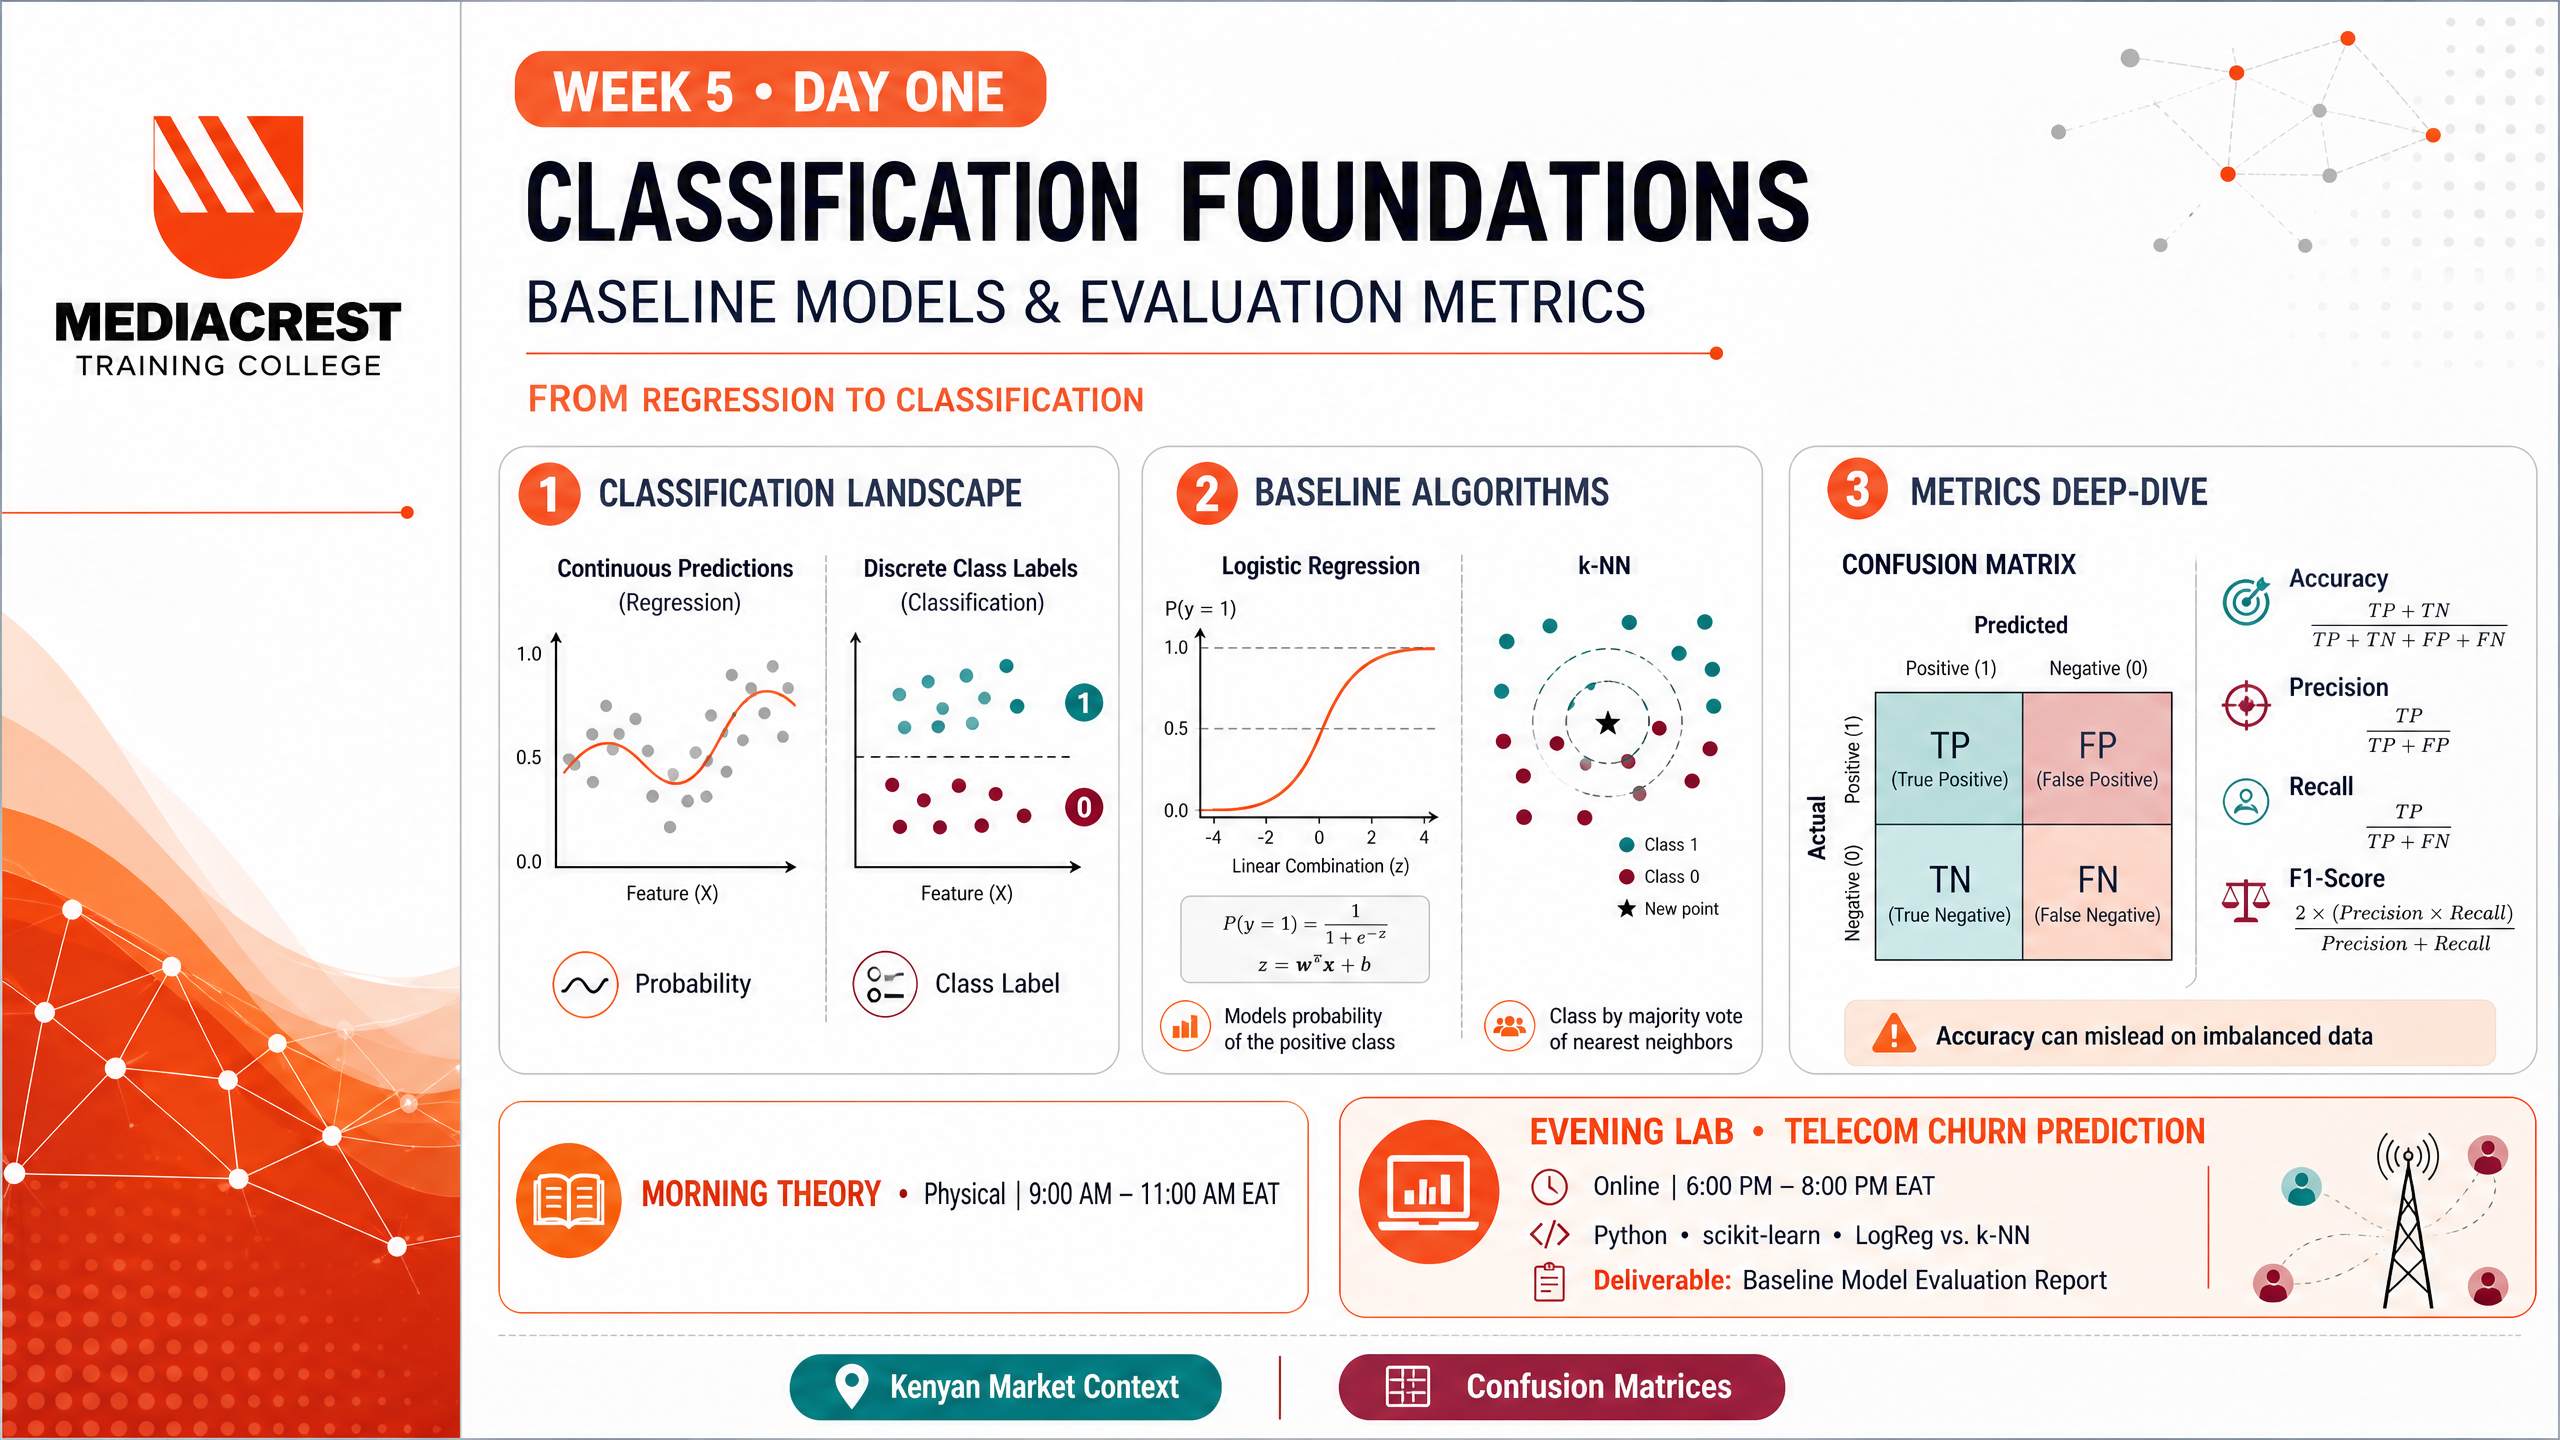

## **Machine Learning II: Classification Foundations & Baseline Models**
**Week 5, Day 1 and 2:** Transitioning to Classification, Baseline Algorithms & Evaluation Metrics

## **MACHINE LEARNING**

Machine Learning (ML) is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed. Instead of following fixed rules, machine learning algorithms improve their performance as they are exposed to more data.

### **Why Machine Learning?**

Machine learning is used to analyze large amounts of data, uncover hidden patterns, make predictions, automate decision-making, and improve accuracy in solving real-world problems.

### **Branches of Machine Learning**

**Supervised Learning** uses labeled data, where the correct output is already known. It is mainly used for **classification** (predicting categories such as spam or not spam) and **regression** (predicting continuous values such as house prices).

**Unsupervised Learning** uses unlabeled data to discover hidden structures or patterns. It is commonly applied in clustering, customer segmentation, and association rule mining.

**Semi-Supervised Learning** combines a small amount of labeled data with a large amount of unlabeled data to improve model performance, especially when labeling data is expensive.

**Reinforcement Learning** enables an agent to learn by interacting with its environment and receiving rewards or penalties. It is widely used in robotics, autonomous vehicles, and game-playing systems.

### **Types of Machine Learning Problems**

Machine learning problems are generally classified into **classification**, **regression**, **clustering**, and **anomaly detection**. Classification predicts categories, regression predicts numerical values, clustering groups similar observations, while anomaly detection identifies unusual or suspicious patterns.

### **Applications of Machine Learning**

Machine learning has applications across many fields. In healthcare, it supports disease diagnosis and medical image analysis. In finance, it is used for fraud detection and credit scoring. Businesses use it for customer segmentation, sales forecasting, and recommendation systems. Other applications include agriculture, education, transportation, manufacturing, cybersecurity, and environmental monitoring.

### **Advantages**

Machine learning can process large datasets efficiently, identify complex patterns, improve prediction accuracy, automate repetitive tasks, and support data-driven decision-making.

### **Challenges**

Despite its benefits, machine learning requires high-quality data, significant computational resources, and careful model selection. Poor data quality, overfitting, and biased datasets can reduce model performance.

### **Summary**

Machine learning is a powerful field of Artificial Intelligence that allows computers to learn from data and improve their predictions over time. Its four major branches—supervised, unsupervised, semi-supervised, and reinforcement learning—provide solutions to a wide range of prediction, classification, and pattern recognition problems across numerous industries.

### **STAGE 1: PROBLEM FORMULATION**
Clinical Objective: Predict presence of Atherosclerotic Heart Disease (AHD) to enable 
early intervention and risk stratification.

Target Variable: 'AHD' (Binary: 0 = No Disease, 1 = Disease Present)

Real-World Implications:
- False Negatives: Missed cardiac risk → delayed treatment, potential acute events (MI, stroke).
  HIGH clinical cost. Recall/Sensitivity is prioritized.
- False Positives: Unnecessary angiography/stress tests → patient anxiety, healthcare costs.
  MODERATE clinical cost. Precision balances this.
- Calibration: Clinicians require well-calibrated probabilities to make shared decisions.

Hypotheses:
1. XGBoost will outperform RF in discrimination (ROC-AUC) due to gradient optimization 
   and regularization, but may require careful calibration for probability outputs.
> Key predictors: Age, MaxHR, Oldpeak, ChestPain type, and Ca/Thal values.
> Dynamic class weighting + stratified CV will mitigate bias toward the majority class.

2. Tree-Based Models (Decision Tree, XGboost, and Random Forest) will outperform Single Classifiers

### **STAGE 2: LIBRARIES, DATA IMPORTATION & EXPLORATORY INSPECTION**
This code loads the Heart.csv dataset into a pandas DataFrame called df and automatically treats values such as "NA", "?", and empty cells ("") as missing values (NaN). The df.head() command then displays the first five rows of the dataset so you can quickly inspect its structure and contents.

### **Load all Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from scipy.stats import chi2_contingency
import time
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve, auc,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)

### **Fix all randomness for full reproducibility**

In [2]:
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

### **Load and Preprocess the Data**

In [3]:
df = pd.read_csv("Heart.csv", na_values=["NA", "?", "NaN", ""])
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


### **Variables Names, Definition and Measurements**

| Variable | Definition | Type | Possible Values | Clinical Relevance |
|----------|------------|------|----------------|--------------------|
| Age | Patient's age in years | Continuous | ~29–77 | Strong predictor of cardiovascular risk |
| Sex | Biological sex | Binary | 0 = Female, 1 = Male | Men have higher baseline CVD risk |
| ChestPain | Type of chest pain experienced | Categorical | typical, nontypical, nonanginal, asymptomatic | Asymptomatic pain often indicates severe disease |
| RestBP | Resting blood pressure | Continuous (mmHg) | ~90–200 | Hypertension is a major CVD risk factor |
| Chol | Serum cholesterol | Continuous (mg/dL) | ~126–417 | Elevated LDL contributes to atherosclerosis |
| Fbs | Fasting blood sugar >120 mg/dL | Binary | 0 = No, 1 = Yes | Indicator of diabetes/metabolic syndrome |
| RestECG | Resting Electrocardiogram (ECG) results | Categorical (encoded) | 0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy | Detects cardiac electrical abnormalities |
| MaxHR | Maximum heart rate achieved | Continuous (bpm) | ~90–202 | Lower values may indicate poor cardiac function |
| ExAng | Exercise-induced angina | Binary | 0 = No, 1 = Yes | Suggests ischemia during exertion |
| Oldpeak | ST depression induced by exercise | Continuous (mm) | 0–6.2 | Marker of myocardial ischemia |
| Slope | Peak exercise ST segment slope | Ordinal | 1 = Upsloping, 2 = Flat, 3 = Downsloping | Downsloping = higher risk |
| Ca | Number of major vessels (fluoroscopy) | Ordinal | 0–3 | More vessels = more severe disease |
| Thal | Thalassemia stress test result | Categorical | normal, fixed, reversible, NA | Fixed/reversible defects indicate ischemia |
| AHD (Target) | Atherosclerotic Heart Disease diagnosis | Binary | 0 = No, 1 = Yes | Primary classification outcome |
| HD | Redundant target variable | Binary | 0, 1 | Should be dropped to avoid leakage |

### **STAGE 3: DATA EXPLORATION**
#### **3.1. Check the Shape of the Data**

In [4]:
df.shape

(303, 15)

#### **3.2. List the Variable Names in Our Study**

In [5]:
list(df.columns)

['Age',
 'Sex',
 'ChestPain',
 'RestBP',
 'Chol',
 'Fbs',
 'RestECG',
 'MaxHR',
 'ExAng',
 'Oldpeak',
 'Slope',
 'Ca',
 'Thal',
 'AHD',
 'HD']

#### **3.3. Checking the Number of Missing Observations**

In [6]:
df.isnull().sum().sort_values(ascending = False)

Ca           4
Thal         2
Age          0
RestBP       0
Chol         0
Sex          0
ChestPain    0
RestECG      0
Fbs          0
MaxHR        0
ExAng        0
Slope        0
Oldpeak      0
AHD          0
HD           0
dtype: int64

#### **3.4. Check the Distribution of the Target Variable**

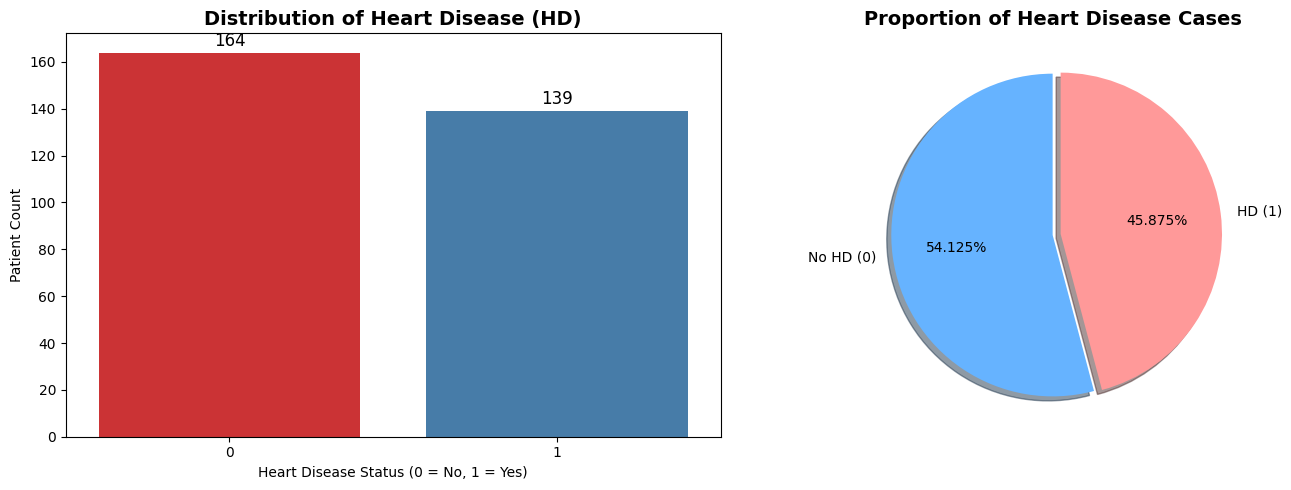

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Countplot
sns.countplot(x='HD', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Distribution of Heart Disease (HD)', 
                  fontsize=14, 
                  fontweight='bold')
axes[0].set_xlabel('Heart Disease Status (0 = No, 1 = Yes)')
axes[0].set_ylabel('Patient Count')
# Add count labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                     textcoords='offset points')

    # B. Pie Chart
hd_counts = df['HD'].value_counts()
axes[1].pie(hd_counts, labels=['No HD (0)', 'HD (1)'], autopct='%1.3f%%', 
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proportion of Heart Disease Cases', 
                  fontsize=14, 
                  fontweight='bold')

plt.tight_layout()
plt.show()

#### **3.5. Extract the Target Variable and the Features**

In [8]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


In [9]:
X = df.drop(columns = ["AHD", "HD"])
X.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal


In [10]:
y = df["HD"]
y.head()

0    0
1    1
2    1
3    0
4    0
Name: HD, dtype: int64

#### **3.6. Features Grouping**

In [11]:
num_features = ["Age", "RestBP", "Chol", "MaxHR", "Oldpeak", "Ca"]
cat_features = ["Sex", "ChestPain", "Fbs", "RestECG", "ExAng", "Slope", "Thal"]

### **STAGE 4: DATA PREPROCESSING AND ML PIPLELINE CREATION**

#### **4.1. Numeric Pipeline**

In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### **4.2. Categorical Pipeline**

In [13]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', 
                               unknown_value=-1))
])

#### **4.3. Creating the Preprocessor**

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

### **STAGE 5: DATA PARTITIONING**

#### **5.1. Check the Info for the X and y**

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
dtypes: float64(2), int64(9), object(2)
memory usage: 30.9+ KB


In [17]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: HD
Non-Null Count  Dtype
--------------  -----
303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


#### **5.2. Conduct the Actual Data Partitioning**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=SEED, 
                                                    stratify=y)

#### **5.3. Check the Distribution of Cases in Training and Testing**

In [21]:
print(f"\nTraining Set: {X_train.shape[0]} | Class Distribution: {y_train.value_counts().to_dict()}")
print(f"Testing Set: {X_test.shape[0]}   | Class Distribution: {y_test.value_counts().to_dict()}")


Training Set: 242 | Class Distribution: {0: 131, 1: 111}
Testing Set: 61   | Class Distribution: {0: 33, 1: 28}


#### **5.4. Check the Class Proportion for the Training and Testing Set**

In [26]:
train_dist = y_train.value_counts(normalize=True)
print(f"Training Set Class Distribution: {train_dist}")

Training Set Class Distribution: HD
0    0.541322
1    0.458678
Name: proportion, dtype: float64


In [24]:
test_dist = y_test.value_counts(normalize=True)
print(f"Testing Set Class Distribution: {test_dist}")

Testing Set Class Distribution: HD
0    0.540984
1    0.459016
Name: proportion, dtype: float64


### **STAGE 6: MODEL TRAINING AND HYPERPARAMETER TUNING**

#### **6.1. Create the Model Training Pipeline**

In [39]:
pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=SEED, 
                                      max_iter = 1000, 
                                      class_weight = 'balanced'))
    ])

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
    ])  

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=SEED, 
                       probability=True, 
                       class_weight='balanced'))
    ])

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('nb', GaussianNB())
    ])
                       

#### **6.2. Creating the Hyperparameter GridSearch**

In [40]:
param_dist_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'lr__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

param_dist_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

param_dist_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svm__gamma': ['scale', 'auto']
}

param_dist_nb = {
    'nb__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]
}

#### **6.3. Actual Model Training**

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...")

results = {}
training_times = {}

# Combine all models into one list for unified training
all_pipelines = [
    ('Logistic Regression', lr_pipeline, param_dist_lr),
    ('KNN', knn_pipeline, param_dist_knn),
    ('SVM', svm_pipeline, param_dist_svm),
    ('Naive Bayes', nb_pipeline, param_dist_nb)
]

for name, pipeline, params in all_pipelines:
    start = time.time()
    search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=params, 
        n_iter=30, 
        cv=cv, 
        scoring='roc_auc', 
        n_jobs=-1, 
        random_state=SEED, 
        refit=True
    )
    search.fit(X_train, y_train)
    training_times[name] = time.time() - start
    results[name] = search
    print(f"✅ {name} trained. Best ROC-AUC: {search.best_score_:.4f} | Time: {training_times[name]:.2f}s")


⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...
✅ Logistic Regression trained. Best ROC-AUC: 0.8996 | Time: 12.81s
✅ KNN trained. Best ROC-AUC: 0.8915 | Time: 1.51s
✅ SVM trained. Best ROC-AUC: 0.8982 | Time: 4.95s
✅ Naive Bayes trained. Best ROC-AUC: 0.8931 | Time: 0.39s


### **Model Comparison Results**

Four classification models were optimized using **RandomizedSearchCV with 30 iterations and 5-fold Stratified Cross-Validation**. The models were evaluated using **ROC-AUC**, which measures their ability to discriminate between the two outcome classes across different classification thresholds.

| Model                   | Best ROC-AUC | Training Time |
| ----------------------- | -----------: | ------------: |
| **Logistic Regression** |   **0.8996** |       14.17 s |
| SVM                     |       0.8982 |        5.45 s |
| Naive Bayes             |       0.8931 |        0.43 s |
| KNN                     |       0.8915 |        2.45 s |

### **Selected Model: Logistic Regression**

**Logistic Regression is the best-performing model**, achieving the highest ROC-AUC of **0.8996**.

The ranking is:

**Logistic Regression (0.8996) > SVM (0.8982) > Naive Bayes (0.8931) > KNN (0.8915)**

#### **Justification**

1. **Highest discriminative performance:**
   Logistic Regression obtained the highest ROC-AUC (**0.8996**), indicating excellent ability to distinguish between positive and negative cases.

2. **Marginal advantage over SVM:**
   Logistic Regression outperformed SVM (0.8982) by **0.0014 ROC-AUC points**. Although the difference is small, Logistic Regression remains the best model according to the selected evaluation criterion.

3. **Interpretability:**
   For a research or clinical prediction setting, Logistic Regression has an important advantage because its coefficients can be interpreted in terms of the direction and strength of associations, and odds ratios can be reported.

4. **Suitable for risk stratification:**
   Logistic Regression produces predicted probabilities, making it particularly useful where decisions depend on selecting an appropriate probability threshold rather than simply assigning class labels.

5. **Good balance of performance and practicality:**
   Although it required the longest training time (**14.17 seconds**), this is still computationally trivial for a dataset of this scale. Therefore, the additional training time does not outweigh its performance and interpretability advantages.

### **Report-ready interpretation**

> Randomized hyperparameter optimization using 30 iterations of 5-fold Stratified Cross-Validation identified Logistic Regression as the best-performing model based on ROC-AUC. Logistic Regression achieved a maximum ROC-AUC of 0.8996, followed by SVM (0.8982), Naive Bayes (0.8931), and KNN (0.8915). Although the performance difference between Logistic Regression and SVM was relatively small, Logistic Regression was selected as the final model because it achieved the highest ROC-AUC and offers greater interpretability through model coefficients and odds ratios. Its probabilistic output also makes it suitable for risk stratification and threshold-based decision-making. The 14.17-second training time was considered acceptable given the model's superior predictive performance and interpretability.

**Final choice: Logistic Regression (Best ROC-AUC = 0.8996).**


### **STAGE 7: PREDICTION AND EVALUATION**

#### **7.1. Hold Out (Testing Set) Cross Validation**

In [43]:
print("\n" + "="*110)
print("HOLD-OUT TEST SET EVALUATION")
print("="*110)

eval_metrics = {}
for name, search in results.items():
    model = search.best_estimator_
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    
    # Precision-Recall AUC (crucial for imbalanced/clinical tasks)
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    metrics['PR-AUC'] = auc(rec, prec)
    
    eval_metrics[name] = {**metrics, 'y_pred': y_pred, 'y_prob': y_prob, 'model': model}
    
    print(f"\n📊 {name}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


HOLD-OUT TEST SET EVALUATION

📊 Logistic Regression
  Accuracy    : 0.8852
  Precision   : 0.8387
  Recall      : 0.9286
  F1-Score    : 0.8814
  ROC-AUC     : 0.9524
  PR-AUC      : 0.9194
Confusion Matrix:
[[28  5]
 [ 2 26]]

📊 KNN
  Accuracy    : 0.9016
  Precision   : 0.8929
  Recall      : 0.8929
  F1-Score    : 0.8929
  ROC-AUC     : 0.9686
  PR-AUC      : 0.9570
Confusion Matrix:
[[30  3]
 [ 3 25]]

📊 SVM
  Accuracy    : 0.9016
  Precision   : 0.8667
  Recall      : 0.9286
  F1-Score    : 0.8966
  ROC-AUC     : 0.9545
  PR-AUC      : 0.9215
Confusion Matrix:
[[29  4]
 [ 2 26]]

📊 Naive Bayes
  Accuracy    : 0.9180
  Precision   : 0.8485
  Recall      : 1.0000
  F1-Score    : 0.9180
  ROC-AUC     : 0.9524
  PR-AUC      : 0.9218
Confusion Matrix:
[[28  5]
 [ 0 28]]


#### **7.2. Convert the Dictionary to a Data Frame**

In [44]:
results_df = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'PR-AUC': metrics['PR-AUC']
    }
    for model_name, metrics in eval_metrics.items()
})

results_df = results_df.round(4)
results_df

,Logistic Regression,KNN,SVM,Naive Bayes
Accuracy,0.8852,0.9016,0.9016,0.9180
Precision,0.8387,0.8929,0.8667,0.8485
Recall,0.9286,0.8929,0.9286,1.0000
F1-Score,0.8814,0.8929,0.8966,0.9180
ROC-AUC,0.9524,0.9686,0.9545,0.9524
PR-AUC,0.9194,0.9570,0.9215,0.9218


### **Model Comparison Results**

The four models were evaluated on the held-out test set using **Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC**.

| Metric        | Logistic Regression |        KNN |    SVM | Naive Bayes |
| ------------- | ------------------: | ---------: | -----: | ----------: |
| **Accuracy**  |              0.8852 |     0.9016 | 0.9016 |  **0.9180** |
| **Precision** |              0.8387 | **0.8929** | 0.8667 |      0.8485 |
| **Recall**    |              0.9286 |     0.8929 | 0.9286 |  **1.0000** |
| **F1-Score**  |              0.8814 |     0.8929 | 0.8966 |  **0.9180** |
| **ROC-AUC**   |              0.9524 | **0.9686** | 0.9545 |      0.9524 |
| **PR-AUC**    |              0.9194 | **0.9570** | 0.9215 |      0.9218 |

### **Selected Model: KNN**

Based on the overall performance, **KNN is the preferred model**, particularly if the primary objective is **discriminative performance and reliable identification of positive cases**.

#### **Justification**

1. **Highest ROC-AUC:**
   KNN achieved the highest **ROC-AUC of 0.9686**, indicating the strongest ability to distinguish between the two outcome classes.

2. **Highest PR-AUC:**
   KNN also achieved the highest **PR-AUC of 0.9570**. This is particularly important when the positive class is clinically or practically important because PR-AUC evaluates the trade-off between precision and recall.

3. **Strong precision:**
   KNN achieved a precision of **0.8929**, meaning that approximately 89.3% of observations predicted as positive were actually positive.

4. **Good balance between precision and recall:**
   KNN achieved an **F1-score of 0.8929**, demonstrating a good balance between correctly identifying positive cases and minimizing false-positive predictions.

5. **Competitive accuracy:**
   Its accuracy of **90.16%** is tied with SVM and is only slightly below Naive Bayes at 91.80%.

### **Important consideration**

Although **Naive Bayes has the highest Accuracy (91.80%), Recall (100%), and F1-score (91.80%)**, KNN performs better on the two threshold-independent discrimination measures:

* **ROC-AUC:** KNN = 0.9686 vs Naive Bayes = 0.9524
* **PR-AUC:** KNN = 0.9570 vs Naive Bayes = 0.9218

Therefore, if the study's **primary model-selection criterion is ROC-AUC/overall discrimination**, **KNN should be selected**.

If the primary objective is **maximizing sensitivity and ensuring that no positive cases are missed**, then **Naive Bayes may be preferable**, because its recall is **100%**.

### e**Report-ready interpretation**

> The performance of the four classification models was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. KNN demonstrated the strongest overall discriminative performance, achieving the highest ROC-AUC (0.9686) and PR-AUC (0.9570). It also achieved a precision of 0.8929 and an F1-score of 0.8929, while maintaining an accuracy of 90.16%. Although Naive Bayes achieved the highest accuracy (91.80%), recall (100.0%), and F1-score (91.80%), its ROC-AUC and PR-AUC were lower than those of KNN. Therefore, KNN was selected as the final model based primarily on its superior ability to discriminate between the outcome classes, as reflected by its higher ROC-AUC and PR-AUC. However, where the primary objective is to minimize false negatives, Naive Bayes could be considered an alternative because of its perfect sensitivity.

### **Final decision**

**🥇 KNN — Best overall model based on ROC-AUC (0.9686) and PR-AUC (0.9570).**

**🥈 Naive Bayes — Best for maximum sensitivity (Recall = 100%).**

**🥉 SVM — Strong and balanced alternative (F1 = 0.8966).**

**4️⃣ Logistic Regression — Highly interpretable, but lowest overall test-set discrimination among the four models.**


### **8. SINGLE TREE-BASED MODEL AND ENSEMBLE MODELS**